<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QG005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

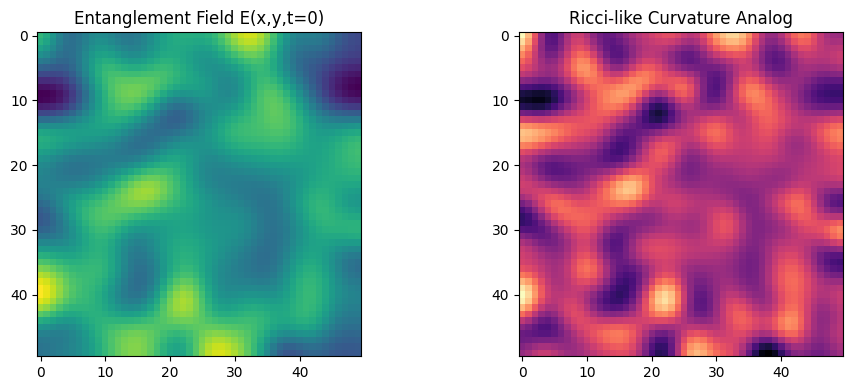

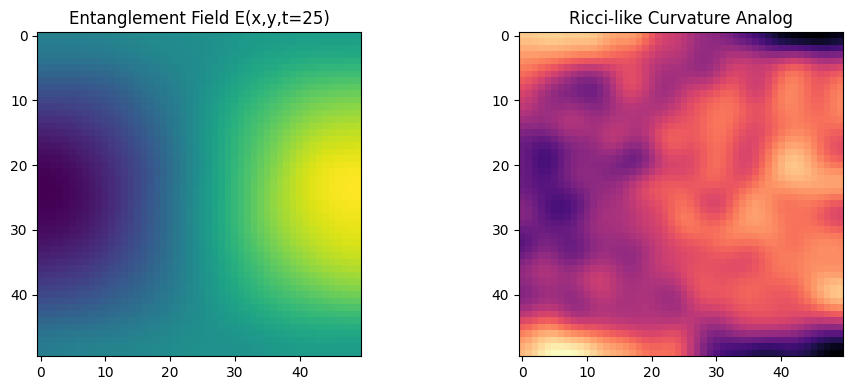

Curvature Fidelity vs t=0 (MSE): 0.0000


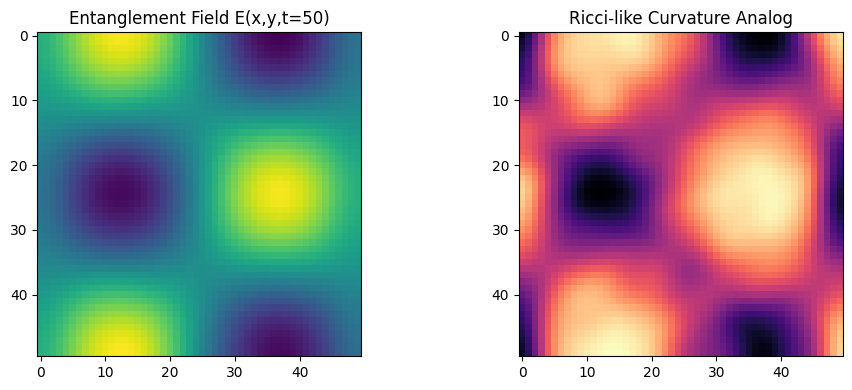

Curvature Fidelity vs t=0 (MSE): 0.0002


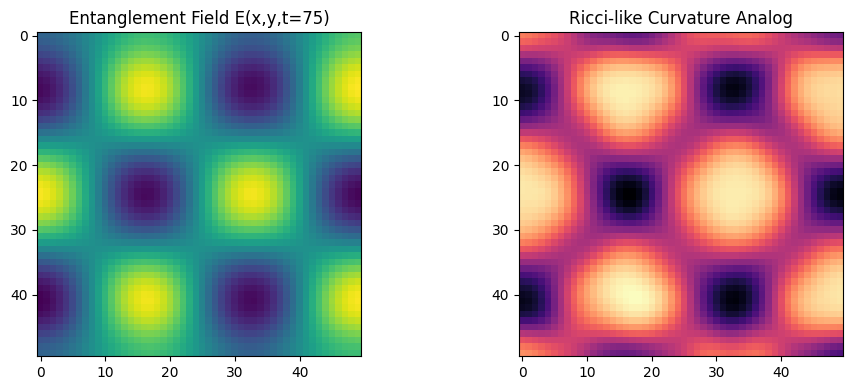

Curvature Fidelity vs t=0 (MSE): 0.0007


In [ ]:
# QG005: Quantum Echo → Geometric Fidelity
# Author: Chris & Copilot
# Arc IV: Quantum Gravity & Emergent Geometry

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, laplace
from sklearn.metrics import mean_squared_error

# Parameters
grid_size = 50
timesteps = [0, 25, 50, 75]
sigma = 3.0  # smoothing for entanglement field

# Initialize entanglement field E(x, y, t)
def initialize_field(t):
    x, y = np.meshgrid(np.linspace(-1, 1, grid_size), np.linspace(-1, 1, grid_size))
    wave = np.sin(2 * np.pi * x * t / 100) * np.cos(2 * np.pi * y * t / 100)
    noise = np.random.normal(0, 0.1, (grid_size, grid_size))
    return gaussian_filter(wave + noise, sigma=sigma)

# Compute curvature analog
def compute_curvature(E):
    grad_x, grad_y = np.gradient(E)
    lap = laplace(E)
    curvature = grad_x**2 + grad_y**2 - lap
    return curvature

# Visualization
def plot_echo(E, curvature, t):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].imshow(E, cmap='viridis')
    axs[0].set_title(f'Entanglement Field E(x,y,t={t})')
    axs[1].imshow(curvature, cmap='magma')
    axs[1].set_title('Ricci-like Curvature Analog')
    plt.tight_layout()
    plt.show()

# Run simulation and compare fidelity
reference_curvature = None
for t in timesteps:
    E = initialize_field(t)
    curvature = compute_curvature(E)
    plot_echo(E, curvature, t)

    if reference_curvature is None:
        reference_curvature = curvature
    else:
        mse = mean_squared_error(reference_curvature.flatten(), curvature.flatten())
        print(f"Curvature Fidelity vs t=0 (MSE): {mse:.4f}")
